In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://api.open-meteo.com/v1/forecast?latitude=51.5074&longitude=-0.1278&hourly=temperature_2m,wind_speed_10m&past_days=7&forecast_days=0"
response = requests.get(url)

if response.status_code == 200:
    raw_data = response.json()  
    print("API Request Successful! Raw Keys Found:", raw_data.keys())
else:
    print(f"Failed to fetch data. Status Code: {response.status_code}")

API Request Successful! Raw Keys Found: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [3]:
hourly_data = raw_data['hourly']
print(hourly_data.keys())

dict_keys(['time', 'temperature_2m', 'wind_speed_10m'])


In [4]:
dt_hourly=pd.DataFrame(hourly_data)
dt_hourly.head()

,time,temperature_2m,wind_speed_10m
0,2026-07-16T00:00,19.4,13.7
1,2026-07-16T01:00,18.7,12.2
2,2026-07-16T02:00,17.9,12.2
3,2026-07-16T03:00,17.4,13.0
4,2026-07-16T04:00,17.3,13.3


In [9]:
dt_hourly.rename(columns={'temperature_2m':'Temperature_C','wind_speed_10m':'Wind_Speed_kmh'},inplace=True)

In [14]:
dt_hourly.head()

,time,Temperature_C,Wind_Speed_kmh
0,2026-07-16 00:00:00,19.4,13.7
1,2026-07-16 01:00:00,18.7,12.2
2,2026-07-16 02:00:00,17.9,12.2
3,2026-07-16 03:00:00,17.4,13.0
4,2026-07-16 04:00:00,17.3,13.3


In [12]:
dt_hourly.time=pd.to_datetime(dt_hourly.time)

In [19]:
print(dt_hourly.duplicated().sum())
print(dt_hourly.isna().sum())

0
time              0
Temperature_C     0
Wind_Speed_kmh    0
dtype: int64


In [20]:
dt_hourly['Date']=dt_hourly.time.dt.date
dt_hourly['Hour']=dt_hourly.time.dt.hour

In [22]:
dt_hourly.head()

,time,Temperature_C,Wind_Speed_kmh,Date,Hour
0,2026-07-16 00:00:00,19.4,13.7,2026-07-16,0
1,2026-07-16 01:00:00,18.7,12.2,2026-07-16,1
2,2026-07-16 02:00:00,17.9,12.2,2026-07-16,2
3,2026-07-16 03:00:00,17.4,13.0,2026-07-16,3
4,2026-07-16 04:00:00,17.3,13.3,2026-07-16,4


In [26]:
daily_summary=dt_hourly.groupby('Date').agg({'Temperature_C':'mean','Wind_Speed_kmh':'max'})
daily_summary

,Temperature_C,Wind_Speed_kmh
Date,,
2026-07-16,22.770833,15.8
2026-07-17,22.379167,15.1
2026-07-18,19.304167,13.7
2026-07-19,18.100000,13.7
2026-07-20,19.400000,12.6
2026-07-21,19.583333,10.1
2026-07-22,21.412500,15.5


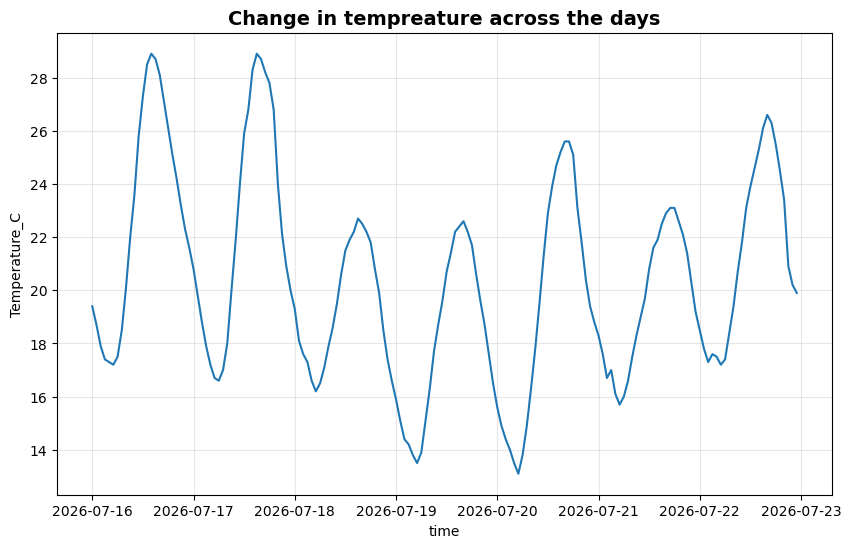

In [28]:
plt.figure(figsize=(10, 6))
sns.lineplot(dt_hourly,x='time',y='Temperature_C')
plt.title('Change in tempreature across the days', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()